# BaB uplift on VNN-COMP 2024 CIFAR-100

This demo uses the VNN-COMP 2024 CIFAR-100 benchmark (199 instances across ResNet-medium and ResNet-large, all with $\varepsilon=1/255\approx0.0039$) to ask a focused question: can batched branch-and-bound (BaB) prove anything stronger than root-level `evaluate_spec`, especially on cases where the root relaxation returns UNKNOWN?

In [1]:
import csv
import json
import logging
import sys
import time
from pathlib import Path

import numpy as np
import torch

act_root = Path.cwd().resolve()
if not (act_root / "act").exists():
    act_root = act_root.parent
if str(act_root) not in sys.path:
    sys.path.insert(0, str(act_root))

from act.util.device_manager import initialize_device, get_default_device, get_default_dtype
from act.front_end.spec_creator_base import LabeledInputTensor
from act.front_end.verifiable_model import InputLayer, InputSpecLayer, OutputSpecLayer, VerifiableModel
from act.front_end.specs import OutputSpec
from act.front_end.vnnlib_loader.onnx_converter import convert_onnx_to_pytorch, get_onnx_input_shape
from act.front_end.vnnlib_loader.vnnlib_parser import parse_vnnlib_to_tensors, parse_vnnlib_queries, extract_label_from_vnnlib
from act.pipeline.verification.torch2act import TorchToACT
from act.back_end.config import BaBConfig
from act.back_end.dual_tf import DualTF, compute_forward_bounds
from act.back_end.solver.solver_dual import DualSolver
import act.back_end.solver.solver_dual as dual_mod
from act.back_end.bab import verify_bab, BoundTrace
import act.back_end.bab.bab as bab_mod
from act.back_end.layer_schema import LayerKind
from act.back_end.bab.eta import get_pre_activation_layer_id
from act.back_end.solver.spec_batching import build_spec_batch as base_build_spec_batch

initialize_device("cuda", "float32")
logging.getLogger("act.front_end.vnnlib_loader").setLevel(logging.ERROR)
logging.getLogger("act.pipeline.verification.act2torch").setLevel(logging.ERROR)

BENCHMARK_DIR = Path("/home/guanqinzhang/data/guanqin/newACT/ACT/data/vnnlib/cifar100_2024")
INSTANCES_CSV = BENCHMARK_DIR / "instances.csv"
ONNX_DIR = BENCHMARK_DIR / "onnx"
VNNLIB_DIR = BENCHMARK_DIR / "vnnlib"

with open(INSTANCES_CSV) as f:
    INSTANCE_ROWS = list(csv.reader(f))
with open(BENCHMARK_DIR / "info.json") as f:
    BENCHMARK_INFO = json.load(f)

print(f"instance count: {BENCHMARK_INFO['num_instances']}")
print("first 5 instance filenames:")
for onnx_rel, vnnlib_rel, _timeout_s in INSTANCE_ROWS[:5]:
    print(f"  - {Path(onnx_rel).name} | {Path(vnnlib_rel).name}")

# With post-fix source, no monkey-patches are needed for CIFAR-100.


[ACT] Auto-detecting project root: ..
[WARN] Gurobi license not found: ../modules/gurobi/gurobi.lic
[INFO] Please place gurobi.lic in: ../modules/gurobi
✅ Device Manager Initialized: device=cuda:0, dtype=torch.float32
instance count: 199
first 5 instance filenames:
  - CIFAR100_resnet_medium.onnx | CIFAR100_resnet_medium_prop_idx_3267_sidx_4884_eps_0.0039.vnnlib
  - CIFAR100_resnet_medium.onnx | CIFAR100_resnet_medium_prop_idx_3965_sidx_688_eps_0.0039.vnnlib
  - CIFAR100_resnet_medium.onnx | CIFAR100_resnet_medium_prop_idx_8028_sidx_5238_eps_0.0039.vnnlib
  - CIFAR100_resnet_medium.onnx | CIFAR100_resnet_medium_prop_idx_3995_sidx_7978_eps_0.0039.vnnlib
  - CIFAR100_resnet_medium.onnx | CIFAR100_resnet_medium_prop_idx_8461_sidx_6823_eps_0.0039.vnnlib


In [2]:
def collect_existing_rows(model_filename):
    rows = []
    for instance_idx, (onnx_rel, vnnlib_rel, timeout_s) in enumerate(INSTANCE_ROWS):
        if Path(onnx_rel).name != model_filename:
            continue
        if not (BENCHMARK_DIR / vnnlib_rel).exists():
            continue
        rows.append(
            {
                "instance_idx": instance_idx,
                "onnx_rel": onnx_rel,
                "vnnlib_rel": vnnlib_rel,
                "timeout_s": float(timeout_s),
            }
        )
    return rows

medium_rows = collect_existing_rows("CIFAR100_resnet_medium.onnx")
large_rows = collect_existing_rows("CIFAR100_resnet_large.onnx")

load_candidates = []
for candidate in [
    ONNX_DIR / "CIFAR100_resnet_medium.onnx",
    *sorted(ONNX_DIR.glob("CIFAR100_resnet_medium*optimized*")),
    ONNX_DIR / "CIFAR100_resnet_large.onnx",
]:
    if candidate.exists() and candidate not in load_candidates:
        load_candidates.append(candidate)

PYTORCH_MODEL = None
MODEL_PATH = None
MODEL_LOAD_S = None
last_error = None
for candidate in load_candidates:
    try:
        t0 = time.time()
        loaded = convert_onnx_to_pytorch(candidate, simplify=True)
        loaded.eval()
        PYTORCH_MODEL = loaded
        MODEL_PATH = candidate
        MODEL_LOAD_S = time.time() - t0
        break
    except Exception as exc:
        last_error = f"{candidate.name}: {type(exc).__name__}: {exc}"

if PYTORCH_MODEL is None:
    raise RuntimeError(f"Unable to load CIFAR-100 ResNet candidates. Last error: {last_error}")

INPUT_SHAPE = get_onnx_input_shape(MODEL_PATH)
source_rows = medium_rows if MODEL_PATH.name.startswith("CIFAR100_resnet_medium") else large_rows
SELECTED_ROWS = source_rows[:3]
assert len(SELECTED_ROWS) == 3, "Need three existing benchmark instances for the demo."

def build_instance_run(row):
    vnnlib_path = BENCHMARK_DIR / row["vnnlib_rel"]
    label = extract_label_from_vnnlib(vnnlib_path)
    if label is None:
        raise RuntimeError(f"Missing label comment in {vnnlib_path.name}")

    input_tensor, _ = parse_vnnlib_to_tensors(vnnlib_path, INPUT_SHAPE)
    labeled = LabeledInputTensor(tensor=input_tensor, label=torch.tensor([label], dtype=torch.int64))
    in_spec, out_spec = parse_vnnlib_queries(vnnlib_path, labeled_tensor=labeled)[0]

    wrapped_model = VerifiableModel(
        input_layer=InputLayer(labeled, labeled.tensor.shape, labeled.tensor.dtype, layout="CHW", dataset_name="cifar100_2024"),
        input_spec=InputSpecLayer(spec=in_spec),
        model=PYTORCH_MODEL,
        output_spec=OutputSpecLayer(spec=out_spec),
    )
    net = TorchToACT(wrapped_model).run()
    net._demo_pytorch_model = PYTORCH_MODEL
    net._demo_input_shape = INPUT_SHAPE

    return {
        "instance_idx": row["instance_idx"],
        "onnx_rel": row["onnx_rel"],
        "vnnlib_rel": row["vnnlib_rel"],
        "timeout_s": row["timeout_s"],
        "vnnlib_path": vnnlib_path,
        "in_spec": in_spec,
        "out_spec": out_spec,
        "net": net,
    }

INSTANCE_RUNS = [build_instance_run(row) for row in SELECTED_ROWS]

print(f"loaded model: {MODEL_PATH.name} (load {MODEL_LOAD_S:.2f}s)")
print(f"input shape: {INPUT_SHAPE}")
print("selected instances:")
for rec in INSTANCE_RUNS:
    print(f"  - instance {rec['instance_idx']}: {rec['vnnlib_path'].name}")


loaded model: CIFAR100_resnet_medium.onnx (load 0.94s)
input shape: (1, 3, 32, 32)
selected instances:
  - instance 1: CIFAR100_resnet_medium_prop_idx_3965_sidx_688_eps_0.0039.vnnlib
  - instance 2: CIFAR100_resnet_medium_prop_idx_8028_sidx_5238_eps_0.0039.vnnlib
  - instance 3: CIFAR100_resnet_medium_prop_idx_3995_sidx_7978_eps_0.0039.vnnlib


In [3]:
ROOT_RESULTS = []
root_solver = DualSolver(DualTF())
print("i | instance_idx | root_margin | root_certified")
print("--|-------------|-------------|---------------")
for i, rec in enumerate(INSTANCE_RUNS):
    t0 = time.time()
    input_lb = rec["in_spec"].lb.flatten(start_dim=1)
    input_ub = rec["in_spec"].ub.flatten(start_dim=1)
    bounds_dict = compute_forward_bounds(rec["net"], input_lb, input_ub)
    spec_result = root_solver.evaluate_spec(rec["net"], bounds_dict, rec["out_spec"], num_classes=100)
    root_margin = float(spec_result.min_slack[0].item())
    root_certified = bool(spec_result.certified[0].item())
    root_time_s = time.time() - t0

    rec["root_margin"] = root_margin
    rec["root_certified"] = root_certified
    rec["root_time_s"] = root_time_s
    ROOT_RESULTS.append(rec)

    print(f"{i} | {rec['instance_idx']} | {root_margin:+.4f} | {root_certified}")


i | instance_idx | root_margin | root_certified
--|-------------|-------------|---------------
0 | 1 | -0.7174 | False
1 | 2 | -3.7914 | False
2 | 3 | -0.6531 | False


In [4]:
PHASE2_TIME_BUDGET_S = 100.0
PHASE2_CONFIG = BaBConfig(
    branching_method="babsr",
    bounding_method="dfs",
    subproblem_batch_size=16,
    eta_iters=10,
    lr_eta=0.05,
    max_nodes=None,
    record_bound_trace=True,
    verbose=True
)

phase2_dual_solver = DualSolver(DualTF())
results_phase2 = []
print(
    f"BaB config: branching={PHASE2_CONFIG.branching_method}, bounding={PHASE2_CONFIG.bounding_method}, "
    f"batch={PHASE2_CONFIG.subproblem_batch_size}, eta_iters={PHASE2_CONFIG.eta_iters}, "
    f"lr_eta={PHASE2_CONFIG.lr_eta}, max_nodes={PHASE2_CONFIG.max_nodes}, "
    f"time_budget_s={PHASE2_TIME_BUDGET_S}, record_bound_trace={PHASE2_CONFIG.record_bound_trace}"
)
print("i | bab_status | bab_nodes | bab_time_s")
print("--|------------|-----------|-----------")
for i, rec in enumerate(INSTANCE_RUNS):
    print(f"--- instance {i + 1} ({rec['vnnlib_path'].name}) ---")
    t0 = time.time()
    bab_result = verify_bab(rec["net"], solver=None, dual_solver=phase2_dual_solver, config=PHASE2_CONFIG, time_budget_s=PHASE2_TIME_BUDGET_S)
    bab_time_s = time.time() - t0

    bab_status = bab_result.status.name
    bab_nodes = int(bab_result.metadata.get("nodes", -1))
    bab_trace = bab_result.metadata.get("bound_trace", None)

    rec["bab_status"] = bab_status
    rec["bab_nodes"] = bab_nodes
    rec["bab_time_s"] = bab_time_s
    rec["bab_trace"] = bab_trace
    results_phase2.append({"i": i, "status": bab_status, "nodes": bab_nodes, "time": bab_time_s, "trace": bab_trace})

    print(f"{i} | {bab_status} | {bab_nodes} | {bab_time_s:.2f}")


BaB config: branching=babsr, bounding=dfs, batch=16, eta_iters=10, lr_eta=0.05, max_nodes=None, time_budget_s=100.0, record_bound_trace=True
i | bab_status | bab_nodes | bab_time_s
--|------------|-----------|-----------
--- instance 1 (CIFAR100_resnet_medium_prop_idx_3965_sidx_688_eps_0.0039.vnnlib) ---
[BaB] iter=  0 node=   1 depth= 0 lb=-0.7174 raw=-0.7174 [open] t=0.39s
[BaB] iter=  0 summary: clamp_hits=0/1 (0%)
[BaB] iter=  1 node=   2 depth= 1 lb=-0.7168 raw=-0.7168 [open] t=0.83s
[BaB] iter=  1 node=   3 depth= 1 lb=-0.7167 raw=-0.7167 [open] t=0.83s
[BaB] iter=  1 summary: clamp_hits=0/2 (0%)
[BaB] iter=  2 node=   4 depth= 2 lb=-0.7153 raw=-0.7153 [open] t=1.41s
[BaB] iter=  2 node=   5 depth= 2 lb=-0.7162 raw=-0.7162 [open] t=1.41s
[BaB] iter=  2 node=   6 depth= 2 lb=-0.7168 raw=-0.7172 CLAMP [open] t=1.41s
[BaB] iter=  2 node=   7 depth= 2 lb=-0.7167 raw=-0.7170 CLAMP [open] t=1.41s
[BaB] iter=  2 summary: clamp_hits=2/4 (50%)
[BaB] iter=  3 node=   8 depth= 3 lb=-0.7080 

INFO:act.back_end.counterexample_io:Counterexample saved to /data1/guanqin/newACT/ACT/act/pipeline/log/counterexamples/unnamed_net_20260424T113436_354282


[BaB] iter=  0 node=   1 depth= 0 lb=-3.7914 raw=-3.7914 [open] t=0.37s
[BaB] iter=  0 summary: clamp_hits=0/1 (0%)
1 | FALSIFIED | 1 | 0.40
--- instance 3 (CIFAR100_resnet_medium_prop_idx_3995_sidx_7978_eps_0.0039.vnnlib) ---
[BaB] iter=  0 node=   1 depth= 0 lb=-0.6531 raw=-0.6531 [open] t=0.37s
[BaB] iter=  0 summary: clamp_hits=0/1 (0%)
[BaB] iter=  1 node=   2 depth= 1 lb=-0.6529 raw=-0.6529 [open] t=0.71s
[BaB] iter=  1 node=   3 depth= 1 lb=-0.6521 raw=-0.6521 [open] t=0.71s
[BaB] iter=  1 summary: clamp_hits=0/2 (0%)
[BaB] iter=  2 node=   4 depth= 2 lb=-0.6044 raw=-0.6044 [open] t=1.53s
[BaB] iter=  2 node=   5 depth= 2 lb=-0.5980 raw=-0.5980 [open] t=1.53s
[BaB] iter=  2 node=   6 depth= 2 lb=-0.6245 raw=-0.6245 [open] t=1.53s
[BaB] iter=  2 node=   7 depth= 2 lb=-0.6183 raw=-0.6183 [open] t=1.53s
[BaB] iter=  2 summary: clamp_hits=0/4 (0%)
[BaB] iter=  3 node=   8 depth= 3 lb=-0.6044 raw=-0.6294 CLAMP [open] t=2.66s
[BaB] iter=  3 node=   9 depth= 3 lb=-0.5980 raw=-0.6233 CL

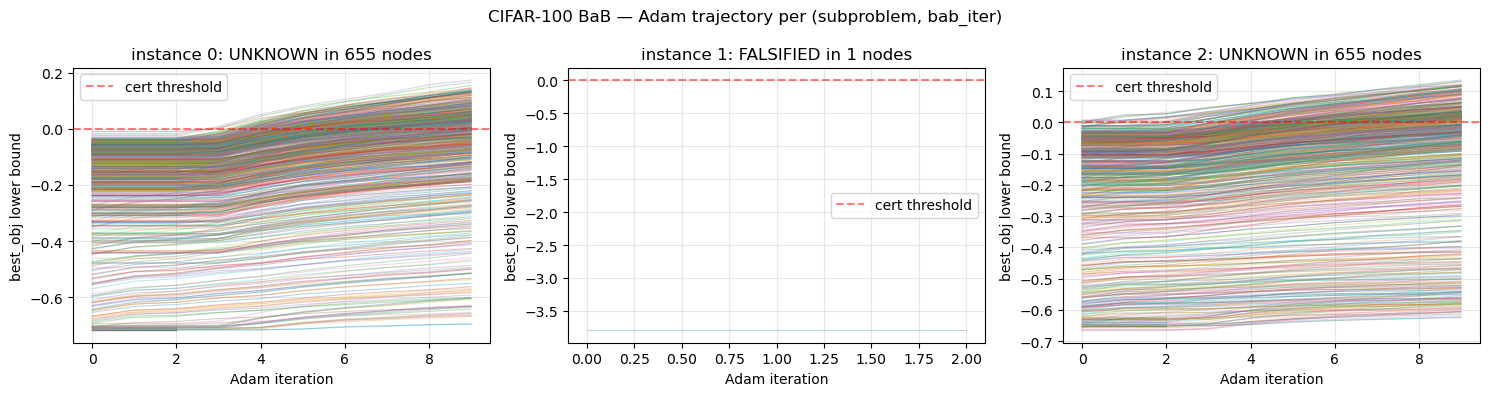

In [5]:
import matplotlib.pyplot as plt

n = len(results_phase2)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, entry in zip(axes, results_phase2):
    trace = entry.get("trace")
    if trace is None or not trace.adam_trajectory:
        ax.set_title(f"instance {entry['i']}: {entry['status']} (no trajectory)")
        ax.grid(True, alpha=0.3)
        continue
    for (sid, bi), traj in trace.adam_trajectory.items():
        if len(traj) >= 2:
            ax.plot(range(len(traj)), traj, alpha=0.3, linewidth=0.8)
    ax.set_xlabel("Adam iteration")
    ax.set_ylabel("best_obj lower bound")
    ax.set_title(f"instance {entry['i']}: {entry['status']} in {entry['nodes']} nodes")
    ax.axhline(0, color="red", ls="--", alpha=0.5, label="cert threshold")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("CIFAR-100 BaB — Adam trajectory per (subproblem, bab_iter)")
fig.tight_layout()
plt.show()


In [6]:
print("CIFAR-100 VNN-COMP 2024 — Phase 1 vs Phase 2 comparison\n")
print(f"{'i':<3} {'Phase1 status':<14} {'Phase1 nodes':<12} {'Phase2 status':<14} {'Phase2 nodes':<12} {'Phase2 time':<12} {'Uplift':<20}")
print("-" * 90)
phase1_counts = [
    ("UNKNOWN", 927, 100.37),
    ("FALSIFIED", 1, 0.11),
    ("UNKNOWN", 911, 100.46),
]
for i, ((p1_status, p1_nodes, _), entry) in enumerate(zip(phase1_counts, results_phase2)):
    p2_status = entry["status"]
    p2_nodes = entry["nodes"]
    p2_time = entry["time"]
    uplift = "no change"
    if p1_status == "UNKNOWN" and p2_status == "CERTIFIED":
        uplift = "UNKNOWN -> CERTIFIED ✓"
    elif p1_status == "UNKNOWN" and p2_status == "FALSIFIED":
        uplift = "UNKNOWN -> FALSIFIED ✓"
    print(f"{i:<3} {p1_status:<14} {p1_nodes:<12} {p2_status:<14} {p2_nodes:<12} {p2_time:<12.2f} {uplift}")

cert_uplift = sum(1 for e, (p1s, _, _) in zip(results_phase2, phase1_counts) if p1s == "UNKNOWN" and e["status"] == "CERTIFIED")
fals_uplift = sum(1 for e, (p1s, _, _) in zip(results_phase2, phase1_counts) if p1s == "UNKNOWN" and e["status"] == "FALSIFIED")
print(f"\nPhase 2 Summary: UNKNOWN -> CERTIFIED: {cert_uplift}, UNKNOWN -> FALSIFIED: {fals_uplift}")


CIFAR-100 VNN-COMP 2024 — Phase 1 vs Phase 2 comparison

i   Phase1 status  Phase1 nodes Phase2 status  Phase2 nodes Phase2 time  Uplift              
------------------------------------------------------------------------------------------
0   UNKNOWN        927          UNKNOWN        655          102.17       no change
1   FALSIFIED      1            FALSIFIED      1            0.40         no change
2   UNKNOWN        911          UNKNOWN        655          101.56       no change

Phase 2 Summary: UNKNOWN -> CERTIFIED: 0, UNKNOWN -> FALSIFIED: 0


## ACASXu VNN-COMP 2023 BaB verification

This section reuses the Phase 2 BaB stack (learnable α + joint α/η KKT + warm-start + Adam trajectory) on the ACAS Xu collision-avoidance benchmark. ACASXu networks are tiny fully-connected MLPs (6 dense layers, 50 hidden units each, 5 inputs, 5 outputs) with VNN-COMP properties encoded as `OutKind.UNSAFE_LINEAR` — a disjunctive spec that is unsafe if *all* constraints $c_k^\top y \le d_k$ hold, i.e. certification requires $\underline{c_k^\top y} > d_k$ for **every** $k$.

We load 3 ACASXu instances through `VNNLibSpecCreator` + `synthesize_models_from_specs`, convert each wrapped model to an ACT Net via `TorchToACT`, compute the root dual bound, then run `verify_bab` with a trace. ACASXu networks are small enough that BaB typically concludes in under 30 s per instance.


In [7]:
from act.front_end.specs import OutKind
from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.model_synthesis import synthesize_models_from_specs

print("="*80)
print("ACASXu — load specs and convert to ACT Net")
print("="*80)

acasxu_creator = VNNLibSpecCreator(config_name="vnnlib_default")
acasxu_spec_results = acasxu_creator.create_specs_for_data_model_pairs(
    categories=["acasxu_2023"],
    max_instances=3,
    validate_shapes=True,
)
acasxu_wrapped = synthesize_models_from_specs(acasxu_spec_results)
print(f"loaded {len(acasxu_wrapped)} wrapped ACASXu instance(s)")

# Build instance-run records modelled on INSTANCE_RUNS for CIFAR-100.
ACASXU_RUNS = []
for combo_id, wm in acasxu_wrapped.items():
    rec_label = ":".join(str(x) for x in combo_id)
    try:
        acasxu_net = TorchToACT(wm).run()
    except NotImplementedError as exc:
        # ACASXu ONNX sometimes contains ops TorchToACT does not yet cover; the
        # current tree supports the common `x - const` input-normalization pattern
        # (see torch2act._process_sub_operation), so this branch should be rare.
        print(f"  [SKIP] {rec_label}: TorchToACT gap -> {str(exc).splitlines()[0]}")
        continue

    in_spec = wm.input_spec.spec
    out_spec = wm.output_spec.spec
    if out_spec.kind != OutKind.UNSAFE_LINEAR:
        print(f"  [SKIP] {rec_label}: unexpected out_spec.kind={out_spec.kind}")
        continue

    in_lb = in_spec.lb.flatten(start_dim=1)
    in_ub = in_spec.ub.flatten(start_dim=1)
    c_mat = out_spec.c if out_spec.c.dim() == 2 else out_spec.c.unsqueeze(0)
    d_vec = out_spec.d.flatten()
    ACASXU_RUNS.append({
        "combo_id": combo_id,
        "label": rec_label,
        "net": acasxu_net,
        "in_spec": in_spec,
        "out_spec": out_spec,
        "n_disjuncts": int(c_mat.shape[0]),
        "n_out": int(c_mat.shape[1]),
        "B": int(in_lb.shape[0]),
    })
    print(f"  + {rec_label}: B={in_lb.shape[0]}, "
          f"in_dim={tuple(in_lb.shape)[1:]}, n_out={c_mat.shape[1]}, "
          f"disjuncts={int(c_mat.shape[0])}")

assert ACASXU_RUNS, "No ACASXu instances available for BaB."
print(f"\n{len(ACASXU_RUNS)} instance(s) ready for ACASXu BaB")


ACASXu — load specs and convert to ACT Net

🧬 Synthesizing models from 3 spec result(s)...

🎉 Synthesis Complete:
   Total specs: 3
   Wrapped models: 3
loaded 3 wrapped ACASXu instance(s)
  + acasxu_2023:ACASXU_run2a_1_2_batch_2000_prop_1:BOX:UNSAFE_LINEAR: B=1, in_dim=(5,), n_out=5, disjuncts=1
  + acasxu_2023:ACASXU_run2a_1_3_batch_2000_prop_1:BOX:UNSAFE_LINEAR: B=1, in_dim=(5,), n_out=5, disjuncts=1
  + acasxu_2023:ACASXU_run2a_1_4_batch_2000_prop_1:BOX:UNSAFE_LINEAR: B=1, in_dim=(5,), n_out=5, disjuncts=1

3 instance(s) ready for ACASXu BaB


In [8]:
print("="*80)
print("ACASXu — root dual bound + BaB")
print("="*80)

ACASXU_TIME_BUDGET_S = 30.0
ACASXU_CONFIG = BaBConfig(
    branching_method="babsr",
    bounding_method="dfs",
    subproblem_batch_size=64,
    eta_iters=10,
    lr_eta=0.05,
    max_nodes=None,
    record_bound_trace=True,
    verbose=True
)
print(
    f"BaB config: branching={ACASXU_CONFIG.branching_method}, bounding={ACASXU_CONFIG.bounding_method}, "
    f"batch={ACASXU_CONFIG.subproblem_batch_size}, eta_iters={ACASXU_CONFIG.eta_iters}, "
    f"lr_eta={ACASXU_CONFIG.lr_eta}, time_budget_s={ACASXU_TIME_BUDGET_S}"
)

acasxu_root_solver = DualSolver(DualTF())
acasxu_bab_solver = DualSolver(DualTF())

results_acasxu = []
for i, rec in enumerate(ACASXU_RUNS):
    print("-"*80)
    print(f"instance {i}: {rec['label']}  (B={rec['B']}, disjuncts={rec['n_disjuncts']})")

    # Root dual bound on the UNSAFE_LINEAR spec (returns one verdict per instance).
    input_lb = rec["in_spec"].lb.flatten(start_dim=1)
    input_ub = rec["in_spec"].ub.flatten(start_dim=1)
    t0 = time.time()
    root_bounds = compute_forward_bounds(rec["net"], input_lb, input_ub)
    root_spec = acasxu_root_solver.evaluate_spec(
        rec["net"], root_bounds, rec["out_spec"], num_classes=rec["n_out"],
    )
    root_time_s = time.time() - t0
    root_min_slack = float(root_spec.slack.min().item())
    root_certified_all = bool(root_spec.certified.all().item())
    root_cert_count = int(root_spec.certified.sum().item())
    print(f"  root: min_slack={root_min_slack:+.4f}, certified={root_cert_count}/{rec['B']} "
          f"(time {root_time_s:.3f}s)")

    # BaB verification (same verify_bab path used by CIFAR-100 cell).
    t0 = time.time()
    bab_result = verify_bab(
        rec["net"], solver=None, dual_solver=acasxu_bab_solver, config=ACASXU_CONFIG,
        time_budget_s=ACASXU_TIME_BUDGET_S,
    )
    bab_time_s = time.time() - t0
    bab_status = bab_result.status.name
    bab_nodes = int(bab_result.metadata.get("nodes", -1))
    bab_trace = bab_result.metadata.get("bound_trace", None)
    print(f"  BaB : status={bab_status}, nodes={bab_nodes}, time={bab_time_s:.2f}s")

    results_acasxu.append({
        "i": i,
        "label": rec["label"],
        "B": rec["B"],
        "n_disjuncts": rec["n_disjuncts"],
        "root_min_slack": root_min_slack,
        "root_cert_count": root_cert_count,
        "root_time_s": root_time_s,
        "status": bab_status,
        "nodes": bab_nodes,
        "time": bab_time_s,
        "trace": bab_trace,
    })


ACASXu — root dual bound + BaB
BaB config: branching=babsr, bounding=dfs, batch=64, eta_iters=10, lr_eta=0.05, time_budget_s=30.0
--------------------------------------------------------------------------------
instance 0: acasxu_2023:ACASXU_run2a_1_2_batch_2000_prop_1:BOX:UNSAFE_LINEAR  (B=1, disjuncts=1)
  root: min_slack=-901.4996, certified=0/1 (time 0.027s)
[BaB] iter=  0 node=   1 depth= 0 lb=-901.4996 raw=-901.4996 [open] t=0.09s
[BaB] iter=  0 summary: clamp_hits=0/1 (0%)
[BaB] iter=  1 node=   2 depth= 1 lb=-779.0639 raw=-779.0639 [open] t=0.21s
[BaB] iter=  1 node=   3 depth= 1 lb=-400.7101 raw=-400.7101 [open] t=0.21s
[BaB] iter=  1 summary: clamp_hits=0/2 (0%)
[BaB] iter=  2 node=   4 depth= 2 lb=-779.0639 raw=-784.1779 CLAMP [open] t=0.34s
[BaB] iter=  2 node=   5 depth= 2 lb=-400.7101 raw=-401.0547 CLAMP [open] t=0.34s
[BaB] iter=  2 node=   6 depth= 2 lb=-770.4528 raw=-770.4528 [open] t=0.34s
[BaB] iter=  2 node=   7 depth= 2 lb=-394.2795 raw=-394.2795 [open] t=0.34s
[Ba

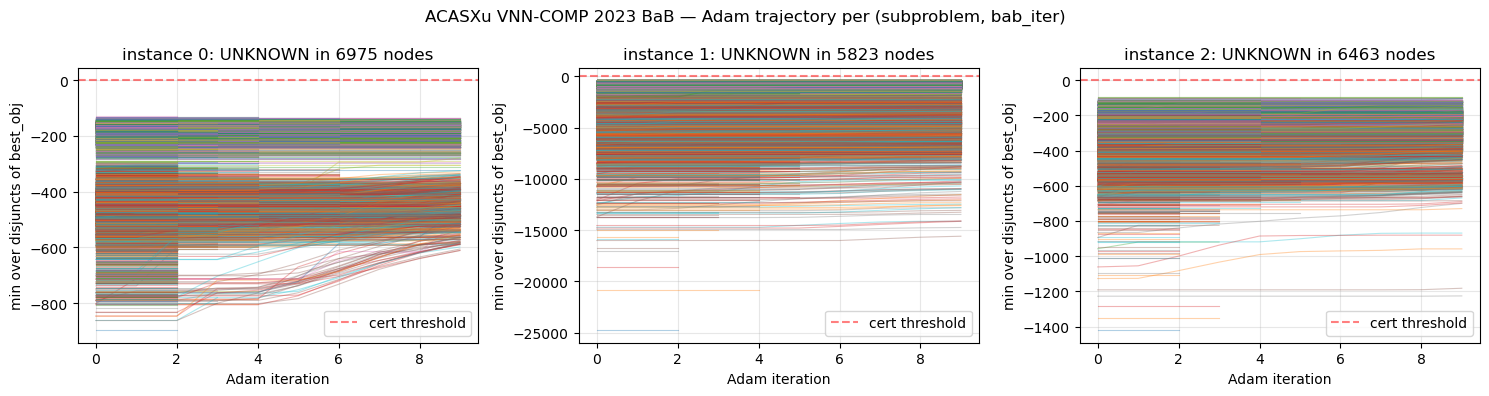

In [9]:
import matplotlib.pyplot as plt

nonempty = [e for e in results_acasxu if e["trace"] is not None and e["trace"].adam_trajectory]
n = max(len(nonempty), 1)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
axes = axes[0]

if not nonempty:
    axes[0].set_title("no ACASXu trajectories recorded")
    axes[0].grid(True, alpha=0.3)
else:
    for ax, entry in zip(axes, nonempty):
        for (sid, bi), traj in entry["trace"].adam_trajectory.items():
            if len(traj) >= 2:
                ax.plot(range(len(traj)), traj, alpha=0.35, linewidth=0.8)
        ax.axhline(0, color="red", ls="--", alpha=0.5, label="cert threshold")
        ax.set_xlabel("Adam iteration")
        ax.set_ylabel("min over disjuncts of best_obj")
        ax.set_title(f"instance {entry['i']}: {entry['status']} in {entry['nodes']} nodes")
        ax.grid(True, alpha=0.3)
        ax.legend()

fig.suptitle("ACASXu VNN-COMP 2023 BaB — Adam trajectory per (subproblem, bab_iter)")
fig.tight_layout()
plt.show()


In [ ]:
print("ACASXu VNN-COMP 2023 BaB summary")
print()
print(f"{'i':<3} {'instance':<60} {'B':<4} {'K':<4} {'root_slack':<12} {'BaB status':<12} {'BaB nodes':<10} {'BaB time':<10}")
print("-" * 120)
for e in results_acasxu:
    label_trim = e["label"] if len(e["label"]) <= 58 else e["label"][:55] + "..."
    print(
        f"{e['i']:<3} {label_trim:<60} {e['B']:<4} {e['n_disjuncts']:<4} "
        f"{e['root_min_slack']:+11.4f}  {e['status']:<12} {e['nodes']:<10} {e['time']:<10.2f}"
    )

cert = sum(1 for e in results_acasxu if e["status"] == "CERTIFIED")
fals = sum(1 for e in results_acasxu if e["status"] == "FALSIFIED")
unk  = sum(1 for e in results_acasxu if e["status"] == "UNKNOWN")
tout = sum(1 for e in results_acasxu if e["status"] == "TIMEOUT")
print(f"\nACASXu tally: CERTIFIED={cert}, FALSIFIED={fals}, UNKNOWN={unk}, TIMEOUT={tout}")


ACASXu VNN-COMP 2023 BaB summary

i   instance                                                     B    K    root_slack   BaB status   BaB nodes  BaB time  
------------------------------------------------------------------------------------------------------------------------
0   acasxu_2023:ACASXU_run2a_1_2_batch_2000_prop_1:BOX:UNSA...   1    1      -901.4996  UNKNOWN      6975       30.04     
1   acasxu_2023:ACASXU_run2a_1_3_batch_2000_prop_1:BOX:UNSA...   1    1    -24756.4766  UNKNOWN      5823       30.11     
2   acasxu_2023:ACASXU_run2a_1_4_batch_2000_prop_1:BOX:UNSA...   1    1     -1424.0751  UNKNOWN      6463       30.10     

ACASXu tally: CERTIFIED=0, FALSIFIED=0, UNKNOWN=3, TIMEOUT=0


: 